# 00c — HRRR Wind Climatology

Builds `WindCellValues` frequency tables for FSPro from HRRR 10m wind analysis at fire occurrence locations.
Also produces exploratory visualizations of the per-pyrome wind climatology.

**Workflow:**
1. Filter FOD to HRRR archive period (2016+)
2. Download HRRR UGRD/VGRD at fire hours (19–22Z) via Herbie — cached to disk
3. Extract wind at each fire location using a KD-tree
4. Build 6-speed × 8-direction frequency tables per pyrome → JSON cache
5. Visualize: wind rose grid, heat maps, speed/direction summaries, spatial map

**Cache location:** `data/weather/pyrome_wind/pyrome_{id}_wind.json`  
**GRIB cache:** `data/weather/hrrr_cache/` (~6 GB for CO 2016–2023)

In [1]:
import os
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from pathlib import Path
from os.path import join
from fb_tools.weather import (
    build_pyrome_wind_cells,
    load_pyrome_wind_cells,
    dominant_wind_direction,
    build_hrrr_wind_percentiles,
)

projdir = Path.cwd().parents[1]
print(f"Project directory: {projdir}")

# Paths
fod_path    = projdir / 'data/spatial/raw/fpa_fod/SHP/Fires_ClassDEFG_CO_Pyromes.shp'
pyrome_path = projdir / 'data/spatial/raw/boundaries/CO_Pyromes.gpkg'
hrrr_cache  = Path('data/weather/hrrr_cache')       # relative: GRIBs live in notebooks/data/
wind_cache  = projdir / 'data/weather/pyrome_wind'  # projdir-relative: JSON cache at project root

proj_crs = 26913  # NAD83 UTM Zone 13N
print(f"HRRR GRIB cache : {hrrr_cache.resolve()}")
print(f"Wind JSON cache : {wind_cache}")
print(f"  JSON files found: {len(list(wind_cache.glob('pyrome_*[0-9]_wind.json')))}")
print('Ready.')

Project directory: /Users/mcc/Library/CloudStorage/Box-Box/MCC/fire_modeling/FM_PythonWrapper
HRRR GRIB cache : /Users/mcc/Library/CloudStorage/Box-Box/MCC/fire_modeling/FM_PythonWrapper/code/notebooks/data/weather/hrrr_cache
Wind JSON cache : /Users/mcc/Library/CloudStorage/Box-Box/MCC/fire_modeling/FM_PythonWrapper/data/weather/pyrome_wind
  JSON files found: 9
Ready.


## 1. Load Fire Data

In [2]:
fod = gpd.read_file(fod_path)
fod['ignition_date'] = pd.to_datetime(fod['DISCOVERY_'])
fod = fod[fod['FIRE_YEAR'] >= 2016].copy()

pyromes = gpd.read_file(pyrome_path)
pyromes = pyromes.to_crs(fod.crs)
fod = gpd.sjoin(fod, pyromes[['PYROME', 'geometry']], how='left', predicate='within')

print(f"FOD (2016+): {len(fod):,} fires")
print(f"Pyromes:     {fod['PYROME'].nunique()} unique pyromes")
print(fod.groupby('PYROME').size().rename('n_fires').to_frame())

FOD (2016+): 957 fires
Pyromes:     9 unique pyromes
        n_fires
PYROME         
42           59
43           74
45           43
46           59
47           90
52          108
53          233
56          223
128          68


## 2. Build Wind Cells (skips if cache exists)

In [3]:
# ── Build wind cell cache ─────────────────────────────────────────────────
# Checks whether JSON files already exist for every pyrome in the FOD.
# If all are present, skips HRRR extraction entirely and just reports.
# To force a rebuild (e.g. to extend the time range), set FORCE_REBUILD=True.
#
# Requires: herbie-data  (pip install herbie-data)
# First-run download for CO 2016–2023: ~1–2 hours, ~6 GB GRIB2 files.
# Re-run from GRIB cache: ~5–10 minutes (extraction only, no downloads).

FORCE_REBUILD = False  # set True to re-extract even if JSON cache exists

expected_pids = set(fod['PYROME'].dropna().astype(str).unique())
existing_files = {f.stem.split('_')[1]: f
                  for f in sorted(wind_cache.glob('pyrome_*[0-9]_wind.json'))}
missing_pids = expected_pids - set(existing_files.keys())

if not FORCE_REBUILD and not missing_pids:
    print(f'Wind cell cache is complete — {len(existing_files)} pyromes found, skipping extraction.')
    print('Files:', [f.name for f in sorted(existing_files.values())])
else:
    if FORCE_REBUILD:
        print('FORCE_REBUILD=True — re-extracting all pyromes.')
    else:
        print(f'Missing JSON for pyromes: {sorted(missing_pids)} — running extraction.')
    wind_cells = build_pyrome_wind_cells(
        fod,
        cache_dir=hrrr_cache,
        out_dir=wind_cache,
        pyrome_col='PYROME',
        n_days=5,
        k_neighbors=9,
        min_obs_warn=200,
    )
    print('Wind cell build complete.')

Wind cell cache is complete — 9 pyromes found, skipping extraction.
Files: ['pyrome_128_wind.json', 'pyrome_42_wind.json', 'pyrome_43_wind.json', 'pyrome_45_wind.json', 'pyrome_46_wind.json', 'pyrome_47_wind.json', 'pyrome_52_wind.json', 'pyrome_53_wind.json', 'pyrome_56_wind.json']


## 3. Load Wind Cell Cache

In [4]:
# Load all cached wind tables without re-running HRRR extraction.
# Use this cell when the JSON cache already exists.

cache_files = sorted(wind_cache.glob('pyrome_*[0-9]_wind.json'))
print(f"Found {len(cache_files)} cached pyrome wind files")

# Build a dict of full metadata for each pyrome
wind_meta = {}
for f in cache_files:
    meta = load_pyrome_wind_cells(f.stem.split('_')[1], wind_cache, return_meta=True)
    pid  = str(meta['pyrome_id'])
    wind_meta[pid] = meta
    c = meta['WindCellValues']
    print(f"  Pyrome {pid:>4}  n_obs={meta['n_observations']:>5}  "
          f"calm={meta['CalmValue']:4.1f}%  "
          f"years={meta['years_covered']}  "
          f"dominant_dir={dominant_wind_direction(pid, wind_cache):.0f}°")

pyrome_ids = sorted(wind_meta.keys(), key=int)

Found 9 cached pyrome wind files
  Pyrome  128  n_obs= 1305  calm= 2.1%  years=2016–2023  dominant_dir=292°
  Pyrome   42  n_obs= 1127  calm= 1.0%  years=2016–2023  dominant_dir=248°
  Pyrome   43  n_obs= 1437  calm= 2.0%  years=2016–2023  dominant_dir=248°
  Pyrome   45  n_obs=  803  calm= 1.9%  years=2016–2023  dominant_dir=292°
  Pyrome   46  n_obs= 1106  calm= 1.3%  years=2016–2023  dominant_dir=292°
  Pyrome   47  n_obs= 1756  calm= 1.3%  years=2016–2023  dominant_dir=248°
  Pyrome   52  n_obs= 2092  calm= 0.9%  years=2016–2023  dominant_dir=158°
  Pyrome   53  n_obs= 4479  calm= 1.2%  years=2016–2023  dominant_dir=202°
  Pyrome   56  n_obs= 4290  calm= 2.3%  years=2016–2023  dominant_dir=338°


## 4. Wind Rose Grid

Each panel is a polar bar chart showing the directional frequency for one pyrome, with bars colored by speed class.

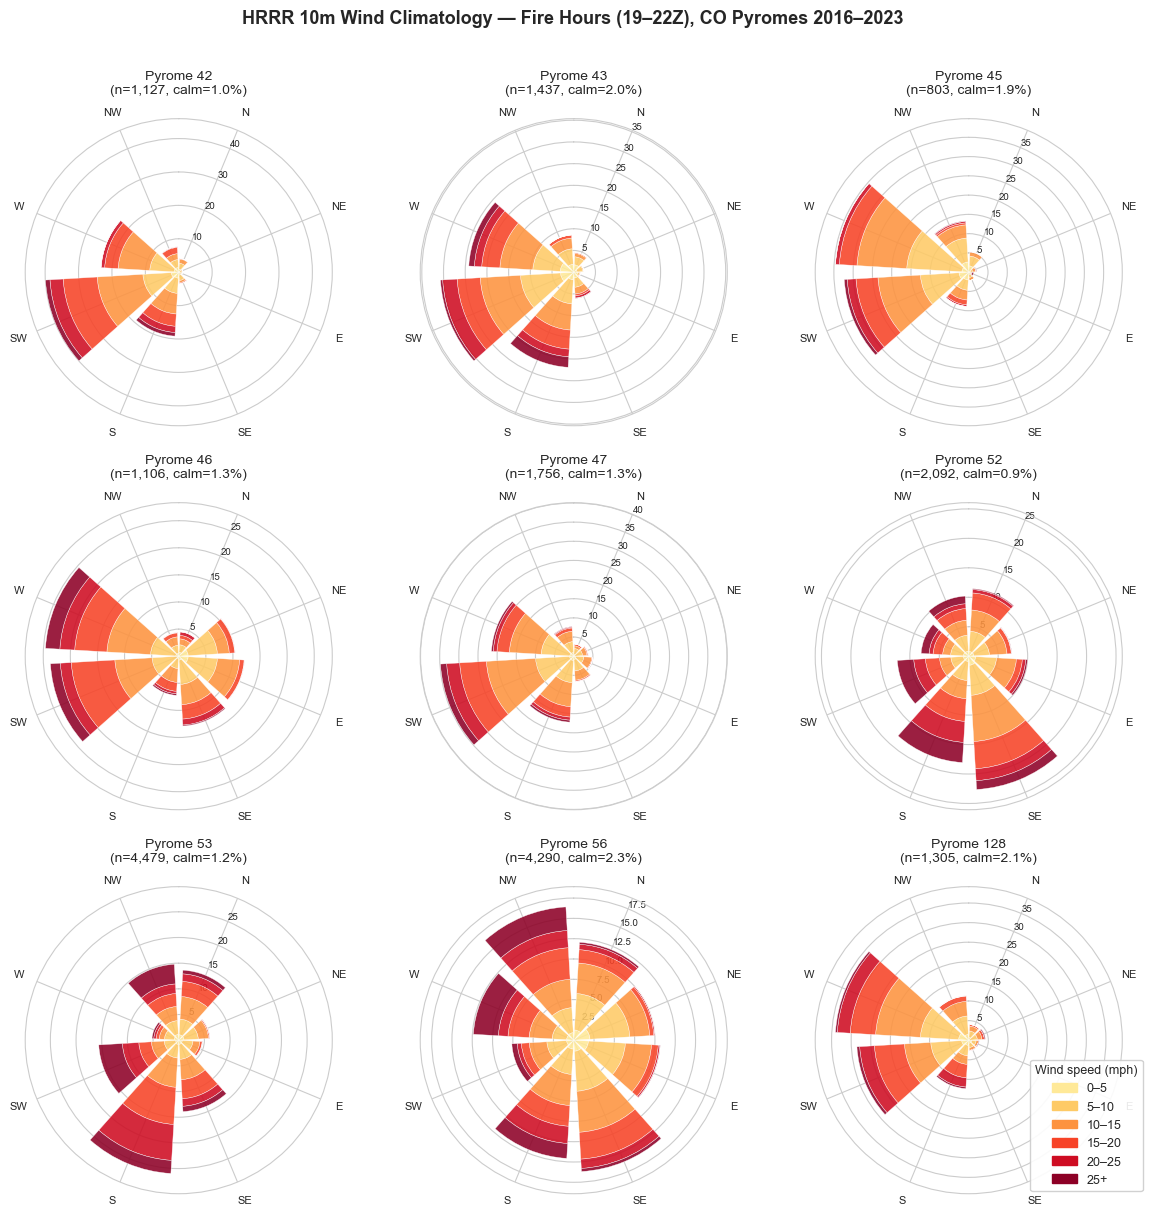

Saved: figures/hrrr_wind_rose_grid.png


In [5]:
# ── Wind rose grid ─────────────────────────────────────────────────────────
# Polar bar chart: theta = wind direction FROM (met convention), bars
# stacked by speed class.  set_theta_zero_location('N') + clockwise so
# N is at top and directions read like a compass.

SPEED_LABELS = ['0–5', '5–10', '10–15', '15–20', '20–25', '25+']  # mph
DIR_LABELS   = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']

# Direction bin centres (degrees, FROM convention)
# FSPro dir breaks [45,90,135,180,225,270,315,360] → centres at 22.5, 67.5 ...
dir_centers_deg = np.array([22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5])
# Convert to matplotlib polar (0=E, CCW) then correct to compass (0=N, CW)
# We use set_theta_zero_location + set_theta_direction instead; keep as radians
dir_centers_rad = np.radians(dir_centers_deg)

bar_width = 2 * np.pi / 8 * 0.85  # 85% of 45° bin width
speed_cmap = plt.colormaps['YlOrRd']
speed_colors = [speed_cmap(0.15), speed_cmap(0.30), speed_cmap(0.48),
                speed_cmap(0.65), speed_cmap(0.82), speed_cmap(0.97)]

ncols = 3
nrows = -(-len(pyrome_ids) // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows),
                          subplot_kw={'projection': 'polar'})
axes = axes.ravel()

for idx, pid in enumerate(pyrome_ids):
    ax = axes[idx]
    meta = wind_meta[pid]
    cells = meta['WindCellValues']          # shape (6_speeds, 8_dirs)
    calm_pct = meta['CalmValue']
    n_obs    = meta['n_observations']

    bottom = np.zeros(8)
    for spd_idx, col in enumerate(speed_colors):
        heights = cells[spd_idx, :]
        ax.bar(dir_centers_rad, heights, width=bar_width, bottom=bottom,
               color=col, alpha=0.88, edgecolor='white', linewidth=0.3)
        bottom += heights

    ax.set_theta_zero_location('N')   # 0° (N) at top
    ax.set_theta_direction(-1)        # clockwise (compass convention)
    ax.set_xticks(dir_centers_rad)
    ax.set_xticklabels(DIR_LABELS, fontsize=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_title(f'Pyrome {pid}\n(n={n_obs:,}, calm={calm_pct:.1f}%)', size=10, pad=10)
    ax.set_ylim(0, cells.sum(axis=0).max() * 1.15)

# Hide unused axes
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

# Legend
patches = [plt.matplotlib.patches.Patch(color=c, label=l)
           for c, l in zip(speed_colors, SPEED_LABELS)]
fig.legend(handles=patches, title='Wind speed (mph)',
           loc='lower right', bbox_to_anchor=(0.98, 0.02),
           fontsize=9, title_fontsize=9, framealpha=0.9)

fig.suptitle('HRRR 10m Wind Climatology — Fire Hours (19–22Z), CO Pyromes 2016–2023',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/hrrr_wind_rose_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/hrrr_wind_rose_grid.png')

## 5. WindCellValues Heat Maps

The 6-speed × 8-direction frequency table exactly as FSPro reads it. Each cell shows the % frequency of non-calm observations in that bin. Row sums = speed marginal; column sums = direction marginal.

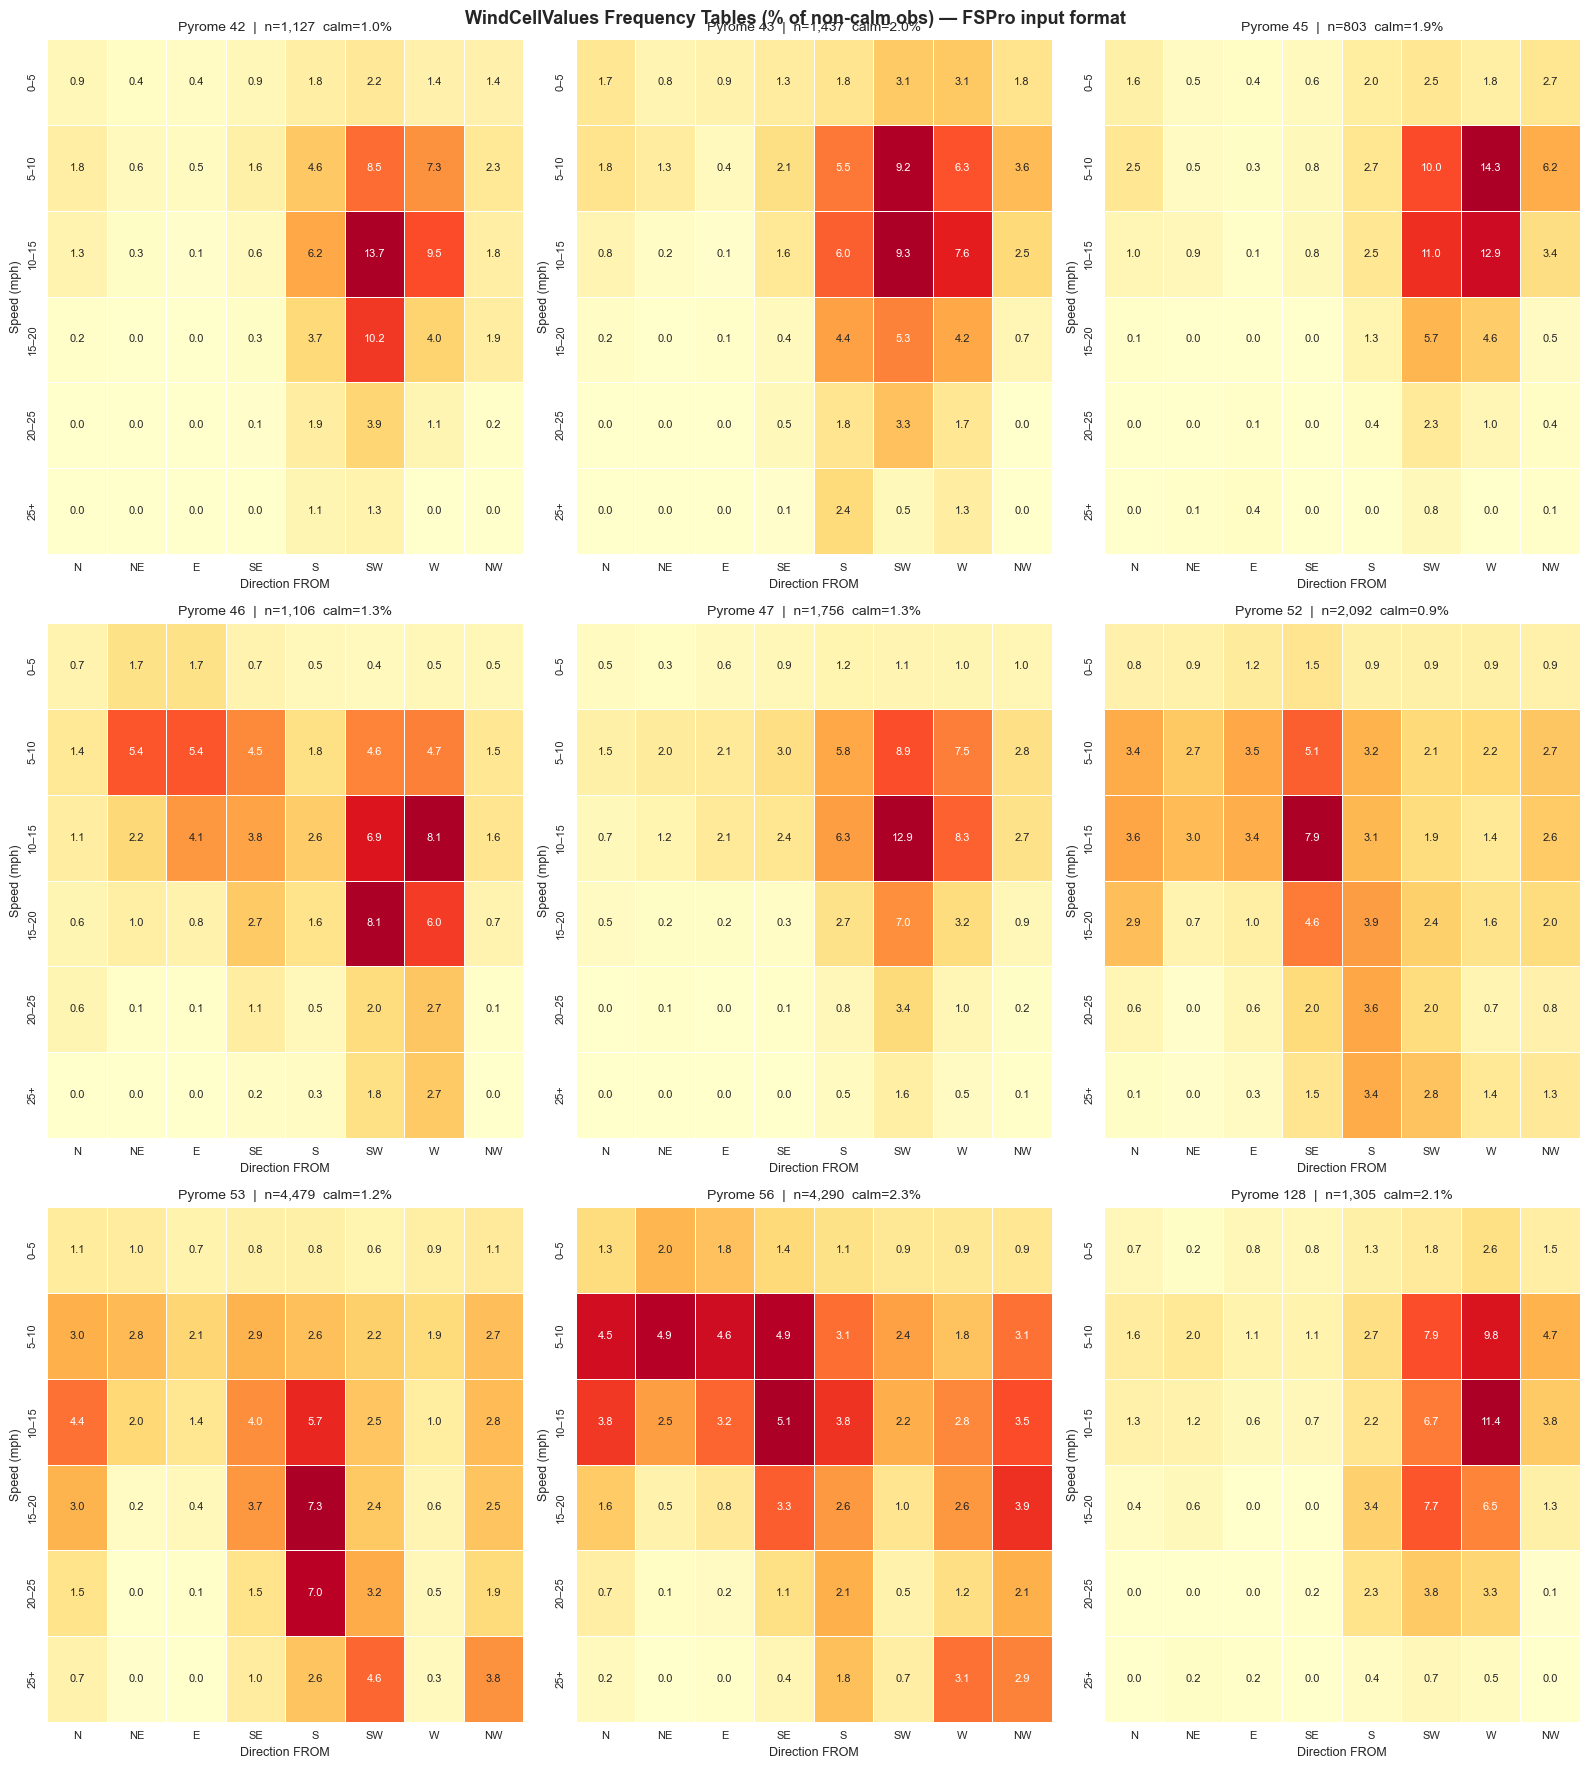

Saved: figures/hrrr_windcell_heatmaps.png


In [6]:
# ── WindCellValues heat maps — all pyromes ──────────────────────────────────
# One heatmap per pyrome; annotated with % values.
# Bottom row/col shows marginal sums.

SPEED_ROWS = ['0–5', '5–10', '10–15', '15–20', '20–25', '25+']
DIR_COLS   = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']

ncols = 3
nrows = -(-len(pyrome_ids) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6 * nrows))
axes = axes.ravel()

for idx, pid in enumerate(pyrome_ids):
    ax = axes[idx]
    meta = wind_meta[pid]
    cells = np.array(meta['WindCellValues'])
    df = pd.DataFrame(cells, index=SPEED_ROWS, columns=DIR_COLS)

    sns.heatmap(
        df, ax=ax,
        annot=True, fmt='.1f', annot_kws={'size': 8},
        cmap='YlOrRd', vmin=0, vmax=df.values.max() * 1.1,
        cbar=False, linewidths=0.5, linecolor='white',
    )
    ax.set_title(
        f'Pyrome {pid}  |  n={meta["n_observations"]:,}  calm={meta["CalmValue"]:.1f}%',
        size=10, pad=6
    )
    ax.set_xlabel('Direction FROM', size=9)
    ax.set_ylabel('Speed (mph)', size=9)
    ax.tick_params(labelsize=8)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('WindCellValues Frequency Tables (% of non-calm obs) — FSPro input format',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/hrrr_windcell_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/hrrr_windcell_heatmaps.png')

## 6. Speed and Direction Marginal Distributions

Comparison across pyromes: marginal speed distribution (left) and marginal direction distribution (right).

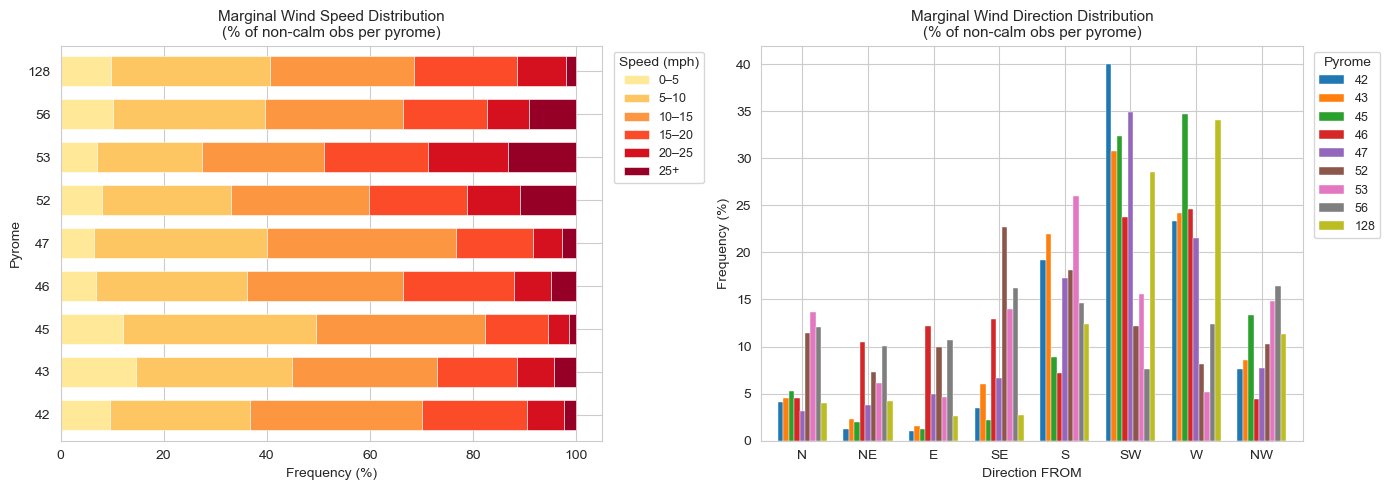

Saved: figures/hrrr_speed_dir_marginals.png


In [7]:
# ── Marginal speed and direction distributions by pyrome ──────────────────

SPEED_LABELS = ['0–5', '5–10', '10–15', '15–20', '20–25', '25+']
DIR_LABELS   = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']

# Collect marginals
spd_df = pd.DataFrame({pid: np.array(wind_meta[pid]['WindCellValues']).sum(axis=1)
                        for pid in pyrome_ids},
                       index=SPEED_LABELS)
dir_df = pd.DataFrame({pid: np.array(wind_meta[pid]['WindCellValues']).sum(axis=0)
                        for pid in pyrome_ids},
                       index=DIR_LABELS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Speed distribution — horizontal stacked bar per pyrome
spd_cmap = plt.colormaps['YlOrRd']
colors = [spd_cmap(v) for v in np.linspace(0.15, 0.95, 6)]
spd_df.T.plot(kind='barh', ax=ax1, stacked=True, color=colors,
               width=0.7, edgecolor='white', linewidth=0.4)
ax1.set_title('Marginal Wind Speed Distribution\n(% of non-calm obs per pyrome)', size=11)
ax1.set_xlabel('Frequency (%)', size=10)
ax1.set_ylabel('Pyrome', size=10)
ax1.legend(title='Speed (mph)', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax1.set_xlim(0, 105)

# Direction distribution — grouped bar chart: x = direction, bars = pyromes
dir_cmap = plt.colormaps['tab10']
dir_colors = [dir_cmap(i / len(pyrome_ids)) for i in range(len(pyrome_ids))]
dir_df.plot(kind='bar', ax=ax2, width=0.75,
             color=dir_colors, edgecolor='white', linewidth=0.3)
ax2.set_title('Marginal Wind Direction Distribution\n(% of non-calm obs per pyrome)', size=11)
ax2.set_xlabel('Direction FROM', size=10)
ax2.set_ylabel('Frequency (%)', size=10)
ax2.set_xticklabels(DIR_LABELS, rotation=0)
ax2.legend(title='Pyrome', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('figures/hrrr_speed_dir_marginals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/hrrr_speed_dir_marginals.png')


## 7. Wind Percentiles for FlamMap Scenario Builder

`build_hrrr_wind_percentiles` computes p25/p50/p75/p90/p97 speed from the raw HRRR observations. These feed directly into `build_flammap_scenario_cache()` as the `wind_percentiles` argument, replacing the GridMET daily-mean wind speed.

In [8]:
# ── Wind percentiles from cell cache ──────────────────────────────────────
# Uses WindCellValues bin interpolation; accurate to ~2-3 mph bin resolution.
# For exact percentiles, re-run fetch_hrrr_winds_at_fires and call
# build_hrrr_wind_percentiles(wind_df) on the raw observation DataFrame.

from fb_tools.weather.hrrr import wind_percentiles_from_cell_cache

pcts = wind_percentiles_from_cell_cache(wind_cache)

# Summarise as a DataFrame
rows = []
for pid, data in sorted(pcts.items(), key=lambda x: int(x[0])):
    row = {'pyrome': pid, **data['ws_mph'], 'n_obs': data['n_obs']}
    rows.append(row)
pct_df = pd.DataFrame(rows).set_index('pyrome')
print(pct_df.to_string())

  [wind_percentiles_from_cell_cache] 9 pyromes × 5 percentiles
        p25   p50   p75   p90   p97  n_obs
pyrome                                    
42      7.8  12.0  16.2  19.9  24.6   1127
43      6.7  10.9  15.6  21.1  26.5   1437
45      6.7  10.1  13.9  18.2  23.1    803
46      8.1  12.3  17.0  21.5  27.0   1106
47      7.7  11.4  14.8  19.5  24.7   1756
52      8.4  13.2  19.0  25.4  28.6   2092
53      9.4  14.8  21.2  26.2  28.9   4479
56      7.5  11.9  17.6  24.5  28.4   4290
128     7.5  11.7  16.6  20.8  24.5   1305


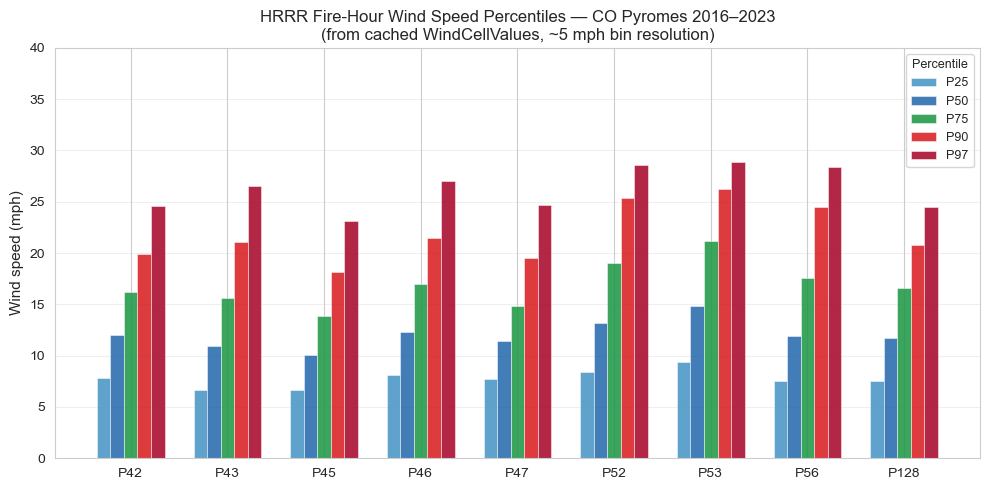

Saved: figures/hrrr_wind_percentiles.png


In [9]:
# ── Wind percentile plot ────────────────────────────────────────────────────
# Box-and-whisker style: p25/p50/p75/p90/p97 per pyrome.
# Each column of pct_df is a speed percentile.

fig, ax = plt.subplots(figsize=(10, 5))

pct_cols = ['p25', 'p50', 'p75', 'p90', 'p97']
colors_p = ['#4393c3', '#2166ac', '#1a9641', '#d7191c', '#a50026']

x = np.arange(len(pct_df))
width = 0.14
for i, (col, color) in enumerate(zip(pct_cols, colors_p)):
    offset = (i - 2) * width
    ax.bar(x + offset, pct_df[col], width=width, color=color, alpha=0.85,
           edgecolor='white', linewidth=0.4, label=col.upper())

ax.set_xticks(x)
ax.set_xticklabels([f'P{pid}' for pid in pct_df.index], fontsize=10)
ax.set_ylabel('Wind speed (mph)', size=11)
ax.set_title('HRRR Fire-Hour Wind Speed Percentiles — CO Pyromes 2016–2023\n'
             '(from cached WindCellValues, ~5 mph bin resolution)', size=12)
ax.legend(title='Percentile', fontsize=9, title_fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 40)

plt.tight_layout()
plt.savefig('figures/hrrr_wind_percentiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/hrrr_wind_percentiles.png')

## 8. Spatial Map — Pyromes + Dominant Wind Direction

CO pyrome polygons colored by dominant wind direction, FOD points, and quiver arrows at pyrome centroids.

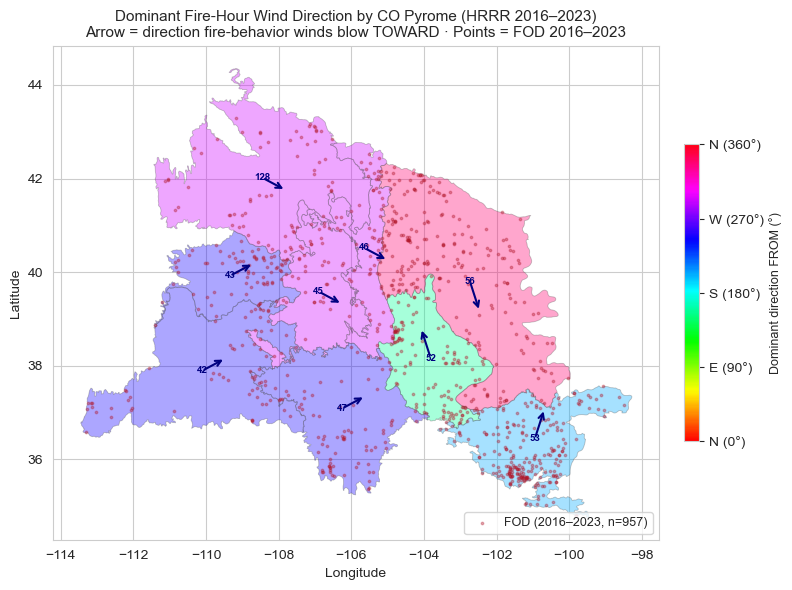

Saved: figures/hrrr_dominant_wind_map.png


In [10]:
# ── Spatial map of dominant wind direction by pyrome ─────────────────────

# Compute dominant direction for each pyrome in cache
dom_dirs = {pid: dominant_wind_direction(pid, wind_cache) for pid in pyrome_ids}

# Merge dominant direction into pyromes GeoDataFrame
pyromes_wgs84 = pyromes.to_crs(4326).copy()
pyromes_wgs84['pyrome_str'] = pyromes_wgs84['PYROME'].astype(str)
pyromes_wgs84['dom_dir'] = pyromes_wgs84['pyrome_str'].map(dom_dirs)

# FOD in WGS84
fod_wgs84 = fod.to_crs(4326)

fig, ax = plt.subplots(figsize=(13, 6))

# Pyromes: color by dominant direction (hue mapped from 0–360)
doms = pyromes_wgs84['dom_dir'].dropna()
norm = mcolors.Normalize(vmin=0, vmax=360)
cmap_wind = plt.colormaps['hsv']  # circular colormap for directions

for _, row in pyromes_wgs84.iterrows():
    pid = row['pyrome_str']
    color = cmap_wind(norm(dom_dirs[pid])) if pid in dom_dirs else 'lightgray'
    gpd.GeoDataFrame([row], crs=4326).plot(
        ax=ax, color=color, alpha=0.35, edgecolor='#555', linewidth=0.6
    )

# FOD points
fod_wgs84.plot(ax=ax, markersize=3, color='#b2182b', alpha=0.35,
                label=f'FOD (2016–2023, n={len(fod_wgs84):,})')

# Dominant wind arrows at pyrome centroids
arrow_scale = 1.0  # degrees of geographic displacement
for _, row in pyromes_wgs84.dropna(subset=['dom_dir']).iterrows():
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    dom = row['dom_dir']
    # FROM direction: wind blowing FROM dom_dir means it's going TO dom_dir+180
    arrow_toward_deg = (dom + 180) % 360
    dx = np.sin(np.radians(arrow_toward_deg)) * arrow_scale * 0.7
    dy = np.cos(np.radians(arrow_toward_deg)) * arrow_scale * 0.7
    ax.annotate('', xy=(cx + dx, cy + dy), xytext=(cx, cy),
                arrowprops=dict(arrowstyle='->', color='navy', lw=1.5))
    ax.text(cx, cy, row['pyrome_str'], ha='center', va='center',
            fontsize=7, fontweight='bold', color='navy')

ax.set_title('Dominant Fire-Hour Wind Direction by CO Pyrome (HRRR 2016–2023)\n'
             'Arrow = direction fire-behavior winds blow TOWARD · Points = FOD 2016–2023',
             size=11)
ax.set_xlabel('Longitude', size=10)
ax.set_ylabel('Latitude', size=10)
ax.legend(fontsize=9, loc='lower right')

# Colorbar for direction
sm = plt.cm.ScalarMappable(cmap=cmap_wind, norm=norm)
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', shrink=0.6, pad=0.02)
cbar.set_label('Dominant direction FROM (°)', size=9)
cbar.set_ticks([0, 90, 180, 270, 360])
cbar.set_ticklabels(['N (0°)', 'E (90°)', 'S (180°)', 'W (270°)', 'N (360°)'])

plt.tight_layout()
plt.savefig('figures/hrrr_dominant_wind_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/hrrr_dominant_wind_map.png')

## 9. FSPro Integration Check

Verify that the wind cells can be loaded by `build_fspro_inputs()` and that `CalmValue + WindCellValues.sum() ≈ 100`.

In [11]:
# ── Sanity check: total frequency accounting ─────────────────────────────
print(f"{'Pyrome':>8}  {'n_obs':>6}  {'calm%':>6}  {'WindCells sum':>14}  "
      f"{'Total (should≈100)':>20}  {'Status'}")
print('-' * 75)

for pid in pyrome_ids:
    meta = wind_meta[pid]
    cells_sum = float(np.array(meta['WindCellValues']).sum())
    total     = cells_sum + meta['CalmValue']
    ok = '✓' if abs(total - 100.0) < 0.5 else '⚠ CHECK'
    print(f"{pid:>8}  {meta['n_observations']:>6,}  {meta['CalmValue']:>6.1f}%  "
          f"{cells_sum:>14.2f}  {total:>20.2f}  {ok}")

  Pyrome   n_obs   calm%   WindCells sum    Total (should≈100)  Status
---------------------------------------------------------------------------
      42   1,127     1.0%          100.00                100.98  ⚠ CHECK
      43   1,437     2.0%          100.00                102.02  ⚠ CHECK
      45     803     1.9%          100.00                101.87  ⚠ CHECK
      46   1,106     1.3%          100.00                101.27  ⚠ CHECK
      47   1,756     1.3%          100.00                101.31  ⚠ CHECK
      52   2,092     0.9%          100.00                100.86  ⚠ CHECK
      53   4,479     1.2%          100.00                101.16  ⚠ CHECK
      56   4,290     2.3%          100.00                102.31  ⚠ CHECK
     128   1,305     2.1%          100.00                102.15  ⚠ CHECK
